In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import tensorflow
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow import data
import os
from tensorflow.keras.callbacks import (
                 EarlyStopping, 
                 ModelCheckpoint, 
                 ReduceLROnPlateau
)
from tensorflow.keras.applications import ResNet152, VGG19, MobileNetV2
from tensorflow.keras.applications.resnet import preprocess_input
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_dir = '/kaggle/input/datasets/nihshu/propcessed-brain-tumor/brain_mri_tumor_prprocessed/train'
test_dir = '/kaggle/input/datasets/nihshu/propcessed-brain-tumor/brain_mri_tumor_prprocessed/test'

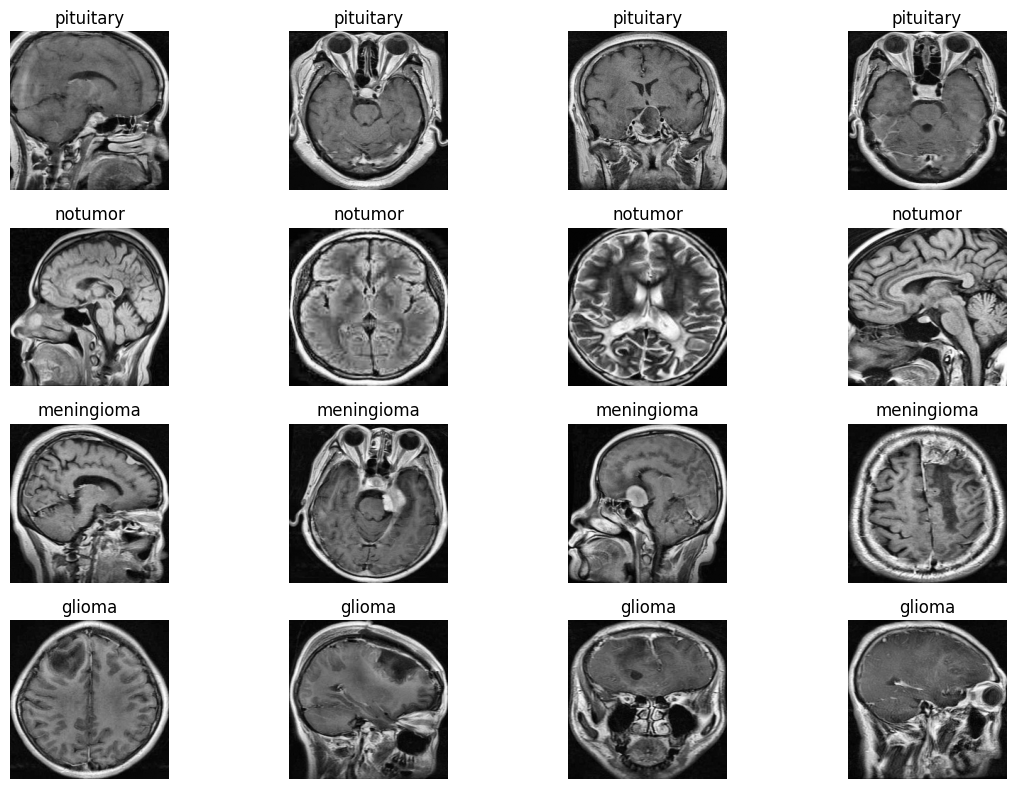

In [3]:
number_of_imgs = 4
classes = os.listdir(train_dir)

plt.figure(figsize = (12, 8))
i = 1

for cls in classes:
    path = os.path.join(train_dir, cls)
    imgs = random.sample(os.listdir(path), 
                         min(number_of_imgs, len(os.listdir(path))))
    
    for img in imgs:
        plt.subplot(len(classes), number_of_imgs, i)
        plt.imshow(Image.open(os.path.join(path, img)), cmap = 'gray')
        plt.title(cls)
        plt.axis('off')
        i += 1

plt.tight_layout()
plt.show()

In [4]:
classes = os.listdir(train_dir)  

img_shapes = {}

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        shape = img.shape
        if shape in img_shapes:
            img_shapes[shape] += 1
        else:
            img_shapes[shape] = 1

print(f'Image size {img_shapes}')

Image size {(224, 224, 3): 5600}


In [5]:
train_ds, val_ds = image_dataset_from_directory(train_dir, 
                                                labels = 'inferred', 
                                                label_mode = 'categorical', 
                                                batch_size = 32, 
                                                seed = 123, 
                                                image_size = (224, 224),
                                                shuffle = True, 
                                                validation_split = 0.2, 
                                                subset = 'both')
print()
test_ds = image_dataset_from_directory(test_dir, labels = 'inferred', 
                                       batch_size = 32, 
                                       image_size = (224, 224), 
                                       label_mode = 'categorical', 
                                       shuffle = False)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Using 1120 files for validation.


I0000 00:00:1775224991.033014      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775224991.039031      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Found 1600 files belonging to 4 classes.


In [6]:
AUTOTUNE = data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size = AUTOTUNE) 
val_ds = val_ds.prefetch(buffer_size = AUTOTUNE)

# BASELINE MODEL

In [7]:
base_model = models.Sequential([
    layers.Input(shape = (224, 224, 3)),
    layers.Rescaling(scale = 1./255), 

    layers.Conv2D(32, (3, 3), padding = 'same', activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3, 3), padding = 'same', activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3, 3), padding = 'same', activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation = 'relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.3),

    layers.Dense(4, activation = 'softmax')
]) 

base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,610,500 (13.77 MB)

 Trainable params: 3,609,540 (13.77 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
base_model.compile(optimizer = tensorflow.keras.optimizers.Adam(learning_rate=0.01), loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [9]:
history = base_model.fit(train_ds, 
                    validation_data = val_ds, 
                    epochs = 10)

Epoch 1/10


I0000 00:00:1775224997.811424     139 service.cc:152] XLA service 0x7bcd00008f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775224997.811463     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775224997.811468     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775224998.541917     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/140 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.2344 - loss: 48.5474

I0000 00:00:1775225006.308491     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 80ms/step - accuracy: 0.3398 - loss: 15.8709 - val_accuracy: 0.2304 - val_loss: 1.5859
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.2564 - loss: 1.5290 - val_accuracy: 0.3571 - val_loss: 1.5612
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.2519 - loss: 1.4342 - val_accuracy: 0.2241 - val_loss: 1.3860
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 67ms/step - accuracy: 0.2482 - loss: 1.4023 - val_accuracy: 0.2214 - val_loss: 1.7220
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.2485 - loss: 1.7763 - val_accuracy: 0.2170 - val_loss: 1.7218
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.2549 - loss: 1.4019 - val_accuracy: 0.2152 - val_loss: 3.6268
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.2387 - loss: 1.4026 - val_accuracy: 0.2214 - val_loss: 1.4266
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.2400 - loss: 1.3876 - val_accuracy:

In [10]:
base_model.evaluate(test_ds)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.5840 - loss: 1.3668


[1.3843494653701782, 0.25187501311302185]

### Baseline model isn't learning anything, using transfer learning
1. ResNet152
2. VGG19
3. MobileNetV2


# ResNet152

In [11]:
ResNet_base = ResNet152(weights = 'imagenet', 
                         include_top = False, 
                         input_tensor = layers.Input(shape = (224, 224, 3)))
ResNet_base.summary()

234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "resnet152"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 58,370,944 (222.67 MB)

 Trainable params: 58,219,520 (222.09 MB)

 Non-trainable params: 151,424 (591.50 KB)

In [12]:
# Freeze the layers in the base model
for layer in ResNet_base.layers:
    layer.trainable = False

In [13]:
ResNet_model = models.Sequential([
    layers.Input(shape = (224, 224, 3)),
    layers.Lambda(preprocess_input), 
    ResNet_base,
    layers.Flatten(),
    layers.Dense(512, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation = 'softmax')  
])
ResNet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152 (Functional)          │ (None, 7, 7, 2048)     │    58,370,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,753,732 (418.68 MB)

 Trainable params: 51,382,788 (196.01 MB)

 Non-trainable params: 58,370,944 (222.67 MB)

In [14]:
ResNet_model.compile(optimizer = 'adam', 
                     loss = 'categorical_crossentropy', 
                     metrics = ['accuracy'])

In [15]:
ResNet_history = ResNet_model.fit(train_ds, 
                            validation_data = val_ds, 
                            epochs = 15)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 89s 429ms/step - accuracy: 0.6944 - loss: 23.8722 - val_accuracy: 0.8687 - val_loss: 0.3202
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 51s 363ms/step - accuracy: 0.8678 - loss: 0.3961 - val_accuracy: 0.9054 - val_loss: 0.2359
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 51s 362ms/step - accuracy: 0.8980 - loss: 0.3006 - val_accuracy: 0.9080 - val_loss: 0.2561
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 51s 364ms/step - accuracy: 0.9028 - loss: 0.2620 - val_accuracy: 0.8955 - val_loss: 0.3183
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 51s 362ms/step - accuracy: 0.9201 - loss: 0.2479 - val_accuracy: 0.9152 - val_loss: 0.3531
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 51s 362ms/step - accuracy: 0.9250 - loss: 0.2478 - val_accuracy: 0.9232 - val_loss: 0.2761
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 51s 364ms/step - accuracy: 0.9251 - loss: 0.2257 - val_accuracy: 0.9170 - val_loss: 0.2562
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 51s 363ms/step - accuracy: 0.9179 - loss: 

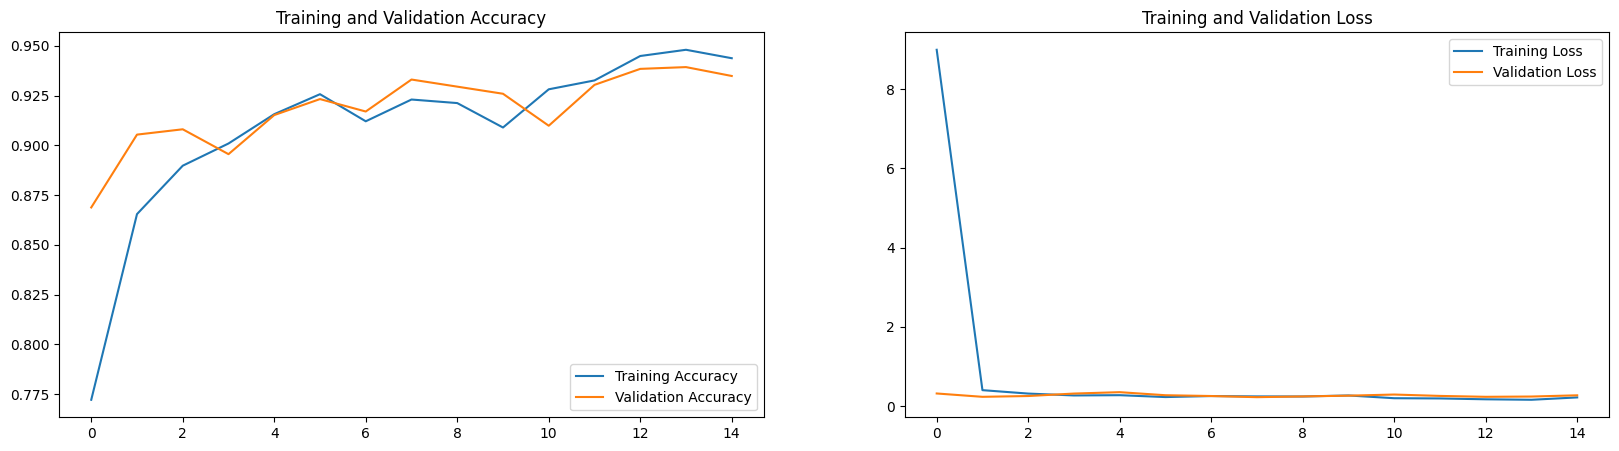

In [16]:
ResNet_acc = ResNet_history.history['accuracy']
ResNet_val_acc = ResNet_history.history['val_accuracy']
ResNet_loss = ResNet_history.history['loss']
ResNet_val_loss = ResNet_history.history['val_loss']

epochs_range = range(len(ResNet_acc))

plt.figure(figsize = (20, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, ResNet_acc, label = 'Training Accuracy')
plt.plot(epochs_range, ResNet_val_acc, label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, ResNet_loss, label = 'Training Loss')
plt.plot(epochs_range, ResNet_val_loss, label = 'Validation Loss')
plt.legend(loc = 'upper right')
plt.title('Training and Validation Loss')
plt.show()

In [56]:
resnet_loss, resnet_acc = ResNet_model.evaluate(test_ds)
print(f"Test Accuracy: {resnet_acc*100:.2f}%")
print(f"Test Loss: {resnet_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 262ms/step - accuracy: 0.8628 - loss: 0.8109
Test Accuracy: 92.12%
Test Loss: 0.4197


In [19]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = ResNet_model.predict(images, verbose=0)
    
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

In [22]:
cm = confusion_matrix(y_true, y_pred)

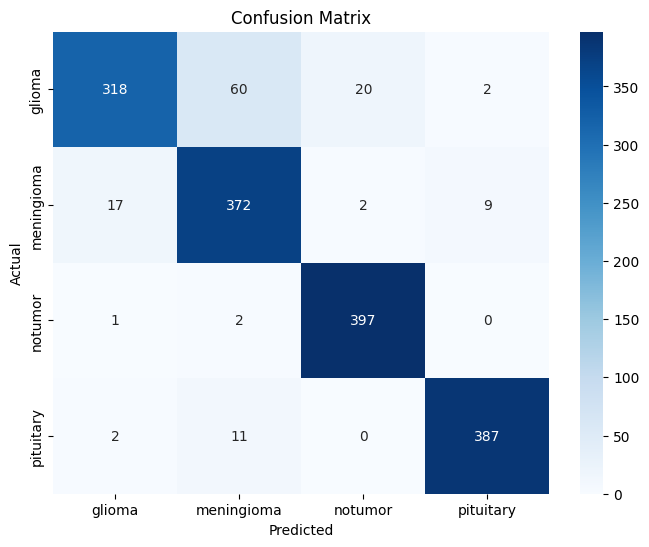

In [24]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# VGG19

In [34]:
vgg19_base = VGG19(include_top = False, 
                   weights = "imagenet", 
                   input_tensor = layers.Input(shape = (224, 224, 3)))
vgg19_base.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 20,024,384 (76.39 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# Freeze the layers in the base model
for layer in vgg19_base.layers:
    layer.trainable = False

In [36]:
vgg19_model = models.Sequential([
    layers.Input(shape = (224, 224, 3)),
    layers.Rescaling(1./255), 
    vgg19_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation = 'softmax')  
])
vgg19_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289,092 (77.40 MB)

 Trainable params: 264,708 (1.01 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [37]:
vgg19_model.compile(optimizer = 'adam', 
                     loss = 'categorical_crossentropy', 
                     metrics = ['accuracy'])

In [38]:
vgg19_history = vgg19_model.fit(train_ds, 
                            validation_data = val_ds, 
                            epochs = 15)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 51s 348ms/step - accuracy: 0.4933 - loss: 1.1634 - val_accuracy: 0.7866 - val_loss: 0.6084
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 336ms/step - accuracy: 0.7675 - loss: 0.6197 - val_accuracy: 0.7670 - val_loss: 0.5522
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 331ms/step - accuracy: 0.8155 - loss: 0.5079 - val_accuracy: 0.7750 - val_loss: 0.5227
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 330ms/step - accuracy: 0.8373 - loss: 0.4583 - val_accuracy: 0.8687 - val_loss: 0.3930
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 329ms/step - accuracy: 0.8375 - loss: 0.4256 - val_accuracy: 0.8768 - val_loss: 0.3727
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 330ms/step - accuracy: 0.8567 - loss: 0.4021 - val_accuracy: 0.8562 - val_loss: 0.3705
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 330ms/step - accuracy: 0.8561 - loss: 0.3935 - val_accuracy: 0.8589 - val_loss: 0.3801
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 330ms/step - accuracy: 0.8700 - loss: 0

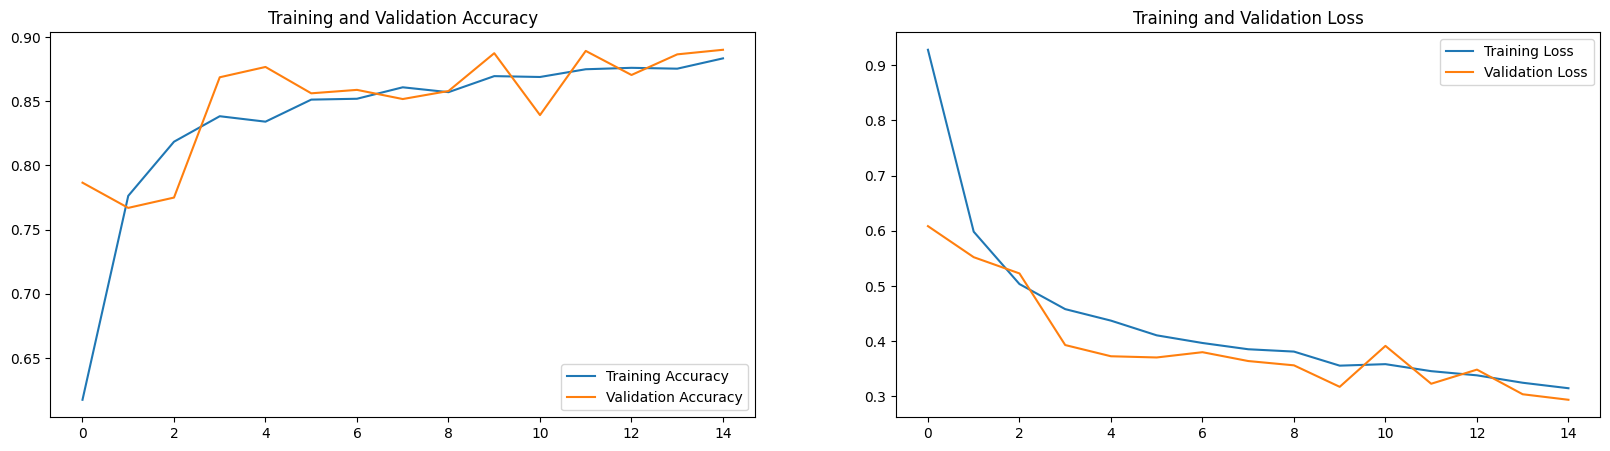

In [39]:
vgg19_acc = vgg19_history.history['accuracy']
vgg19_val_acc = vgg19_history.history['val_accuracy']
vgg19_loss = vgg19_history.history['loss']
vgg19_val_loss = vgg19_history.history['val_loss']

epochs_range = range(len(vgg19_acc))

plt.figure(figsize = (20, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, vgg19_acc, label = 'Training Accuracy')
plt.plot(epochs_range, vgg19_val_acc, label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, vgg19_loss, label = 'Training Loss')
plt.plot(epochs_range, vgg19_val_loss, label = 'Validation Loss')
plt.legend(loc = 'upper right')
plt.title('Training and Validation Loss')
plt.show()

In [59]:
vgg_loss, vgg_acc = vgg19_model.evaluate(test_ds)
print(f"Test Accuracy: {vgg_acc*100:.2f}%")
print(f"Test Loss: {vgg_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 287ms/step - accuracy: 0.7410 - loss: 0.7650
Test Accuracy: 82.63%
Test Loss: 0.4982


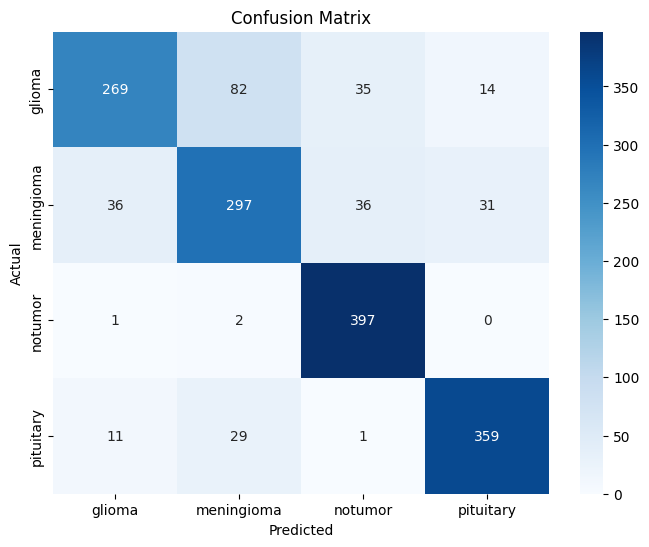

In [60]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = vgg19_model.predict(images, verbose = 0)
    
    y_true.extend(np.argmax(labels.numpy(), axis = 1))
    y_pred.extend(np.argmax(preds, axis = 1))

cm = confusion_matrix(y_true, y_pred)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# MobileNetV2

In [48]:
from tensorflow.keras.applications.mobilenet import preprocess_input

mobilenet_base = MobileNetV2(include_top = False, 
                             weights = 'imagenet', 
                             input_tensor = layers.Input(shape = (224, 224, 3)))
mobilenet_base.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_11[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [49]:
# Freeze the layers in the base model
for layer in mobilenet_base.layers:
    layer.trainable = False

In [50]:
MobileNetV2_model = models.Sequential([
    layers.Input(shape = (224, 224, 3)),
    layers.Lambda(preprocess_input), 
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation = 'softmax')  
])
MobileNetV2_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,915,908 (11.12 MB)

 Trainable params: 657,924 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [51]:
MobileNetV2_model.compile(optimizer = 'adam', 
                     loss = 'categorical_crossentropy', 
                     metrics = ['accuracy'])

In [52]:
MobileNetV2_history = MobileNetV2_model.fit(train_ds, 
                            validation_data = val_ds, 
                            epochs = 15)

Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.7147 - loss: 0.7686 - val_accuracy: 0.8786 - val_loss: 0.3375
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8619 - loss: 0.3712 - val_accuracy: 0.8929 - val_loss: 0.2959
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8871 - loss: 0.3004 - val_accuracy: 0.8420 - val_loss: 0.4054
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.8988 - loss: 0.2753 - val_accuracy: 0.8929 - val_loss: 0.2737
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9054 - loss: 0.2334 - val_accuracy: 0.8911 - val_loss: 0.2654
Epoch 6/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9253 - loss: 0.1968 - val_accuracy: 0.8929 - val_loss: 0.2648
Epoch 7/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9297 - loss: 0.1821 - val_accuracy: 0.8973 - val_loss: 0.2684
Epoch 8/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.9299 - loss: 0.1784 - val_acc

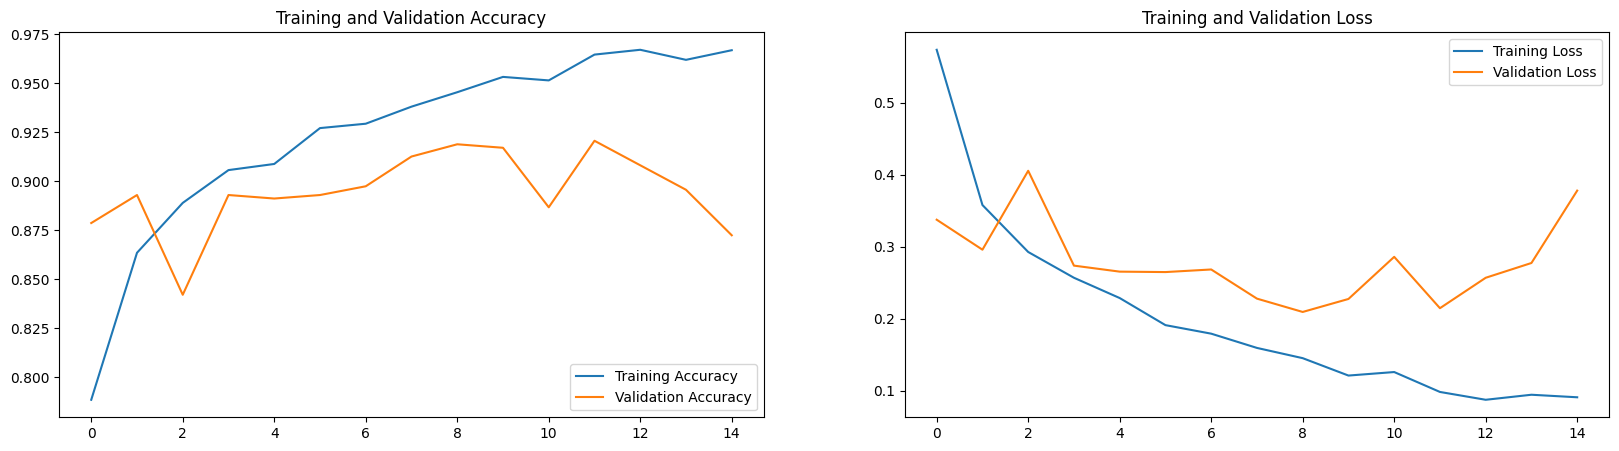

In [53]:
MobileNetV2_acc = MobileNetV2_history.history['accuracy']
MobileNetV2_val_acc = MobileNetV2_history.history['val_accuracy']
MobileNetV2_loss = MobileNetV2_history.history['loss']
MobileNetV2_val_loss = MobileNetV2_history.history['val_loss']

epochs_range = range(len(vgg19_acc))

plt.figure(figsize = (20, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, MobileNetV2_acc, label = 'Training Accuracy')
plt.plot(epochs_range, MobileNetV2_val_acc, label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, MobileNetV2_loss, label = 'Training Loss')
plt.plot(epochs_range, MobileNetV2_val_loss, label = 'Validation Loss')
plt.legend(loc = 'upper right')
plt.title('Training and Validation Loss')
plt.show()

In [61]:
mobilenet_loss, mobilenet_acc = MobileNetV2_model.evaluate(test_ds)
print(f"Test Accuracy: {mobilenet_acc*100:.2f}%")
print(f"Test Loss: {mobilenet_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8414 - loss: 0.6740
Test Accuracy: 88.06%
Test Loss: 0.4526


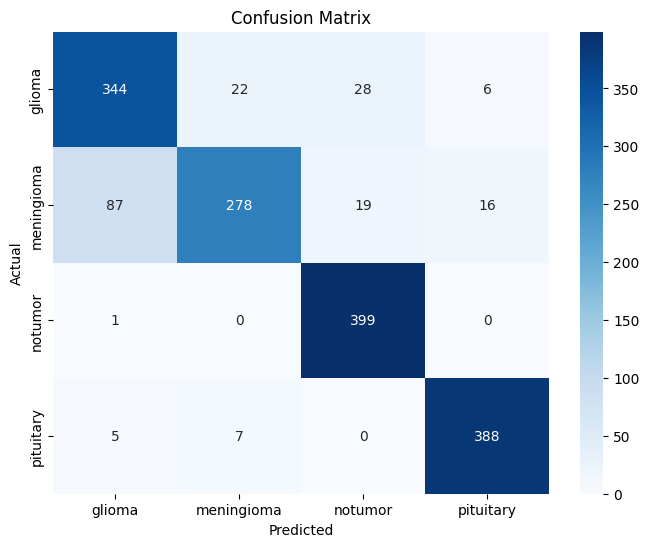

In [62]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = MobileNetV2_model.predict(images, verbose = 0)
    
    y_true.extend(np.argmax(labels.numpy(), axis = 1))
    y_pred.extend(np.argmax(preds, axis = 1))

cm = confusion_matrix(y_true, y_pred)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ALL 3 MODEL COMPARISON

In [63]:
print("ResNet152:", resnet_acc)
print("MobileNetV2:", mobilenet_acc)
print("VGG19:", vgg_acc)

ResNet152: 0.9212499856948853
MobileNetV2: 0.8806250095367432
VGG19: 0.8262500166893005


In [64]:
data = {
    "Model": ["ResNet152", "MobileNetV2", "VGG19"],
    "Accuracy": [resnet_acc, mobilenet_acc, vgg_acc],
    "Loss": [resnet_loss, mobilenet_loss, vgg_loss]
}

df = pd.DataFrame(data)
print(df)

         Model  Accuracy      Loss
0    ResNet152  0.921250  0.419674
1  MobileNetV2  0.880625  0.452627
2        VGG19  0.826250  0.498195


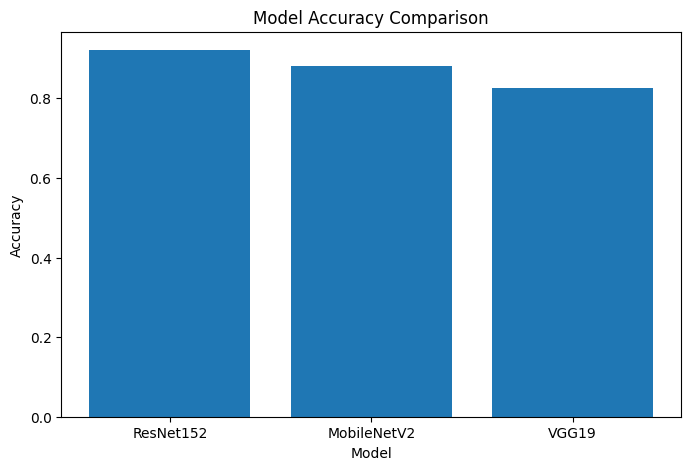

In [65]:
plt.figure(figsize=(8,5))
plt.bar(df["Model"], df["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

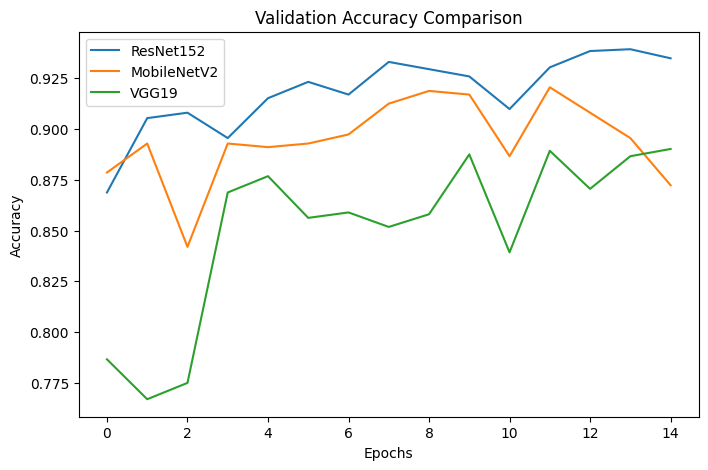

In [66]:
plt.figure(figsize=(8,5))
plt.plot(ResNet_history.history['val_accuracy'], label='ResNet152')
plt.plot(MobileNetV2_history.history['val_accuracy'], label='MobileNetV2')
plt.plot(vgg19_history.history['val_accuracy'], label='VGG19')

plt.legend()
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# CONCLUSION
In this study, three deep learning architectures - **ResNet152**, **MobileNetV2**, and **VGG19**  were evaluated for brain tumor classification using MRI images.

The experimental results demonstrate that ResNet152 achieved the highest performance, with a test accuracy of approximately 92.12%, followed by MobileNetV2 (88.06%) and VGG19 (82.62%). ResNet152 also showed the most stable training and validation curves, indicating better generalization capability.

Overall, the results suggest that ResNet152 is the most effective model for this task, while MobileNetV2 can be considered when computational efficiency is a priority.

### will Improve Scores **ResNet152** with Fine tunning.